# Autoencoders

Un **autoencoder** es una red neuronal entrenada para aprender una representacion comprimida de los datos y luego reconstruirlos.

Tiene un **codificador** y un ***decodificador**. El primero comprime las entradas, el segundo las descomprime de la manera más exacta posible.

## Importo librerias

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, datasets

## Importo set de datos


In [33]:
(x_train, _), (x_test, _) = datasets.fashion_mnist.load_data()

## Trabajo sobre el set de datos

In [34]:
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

In [35]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

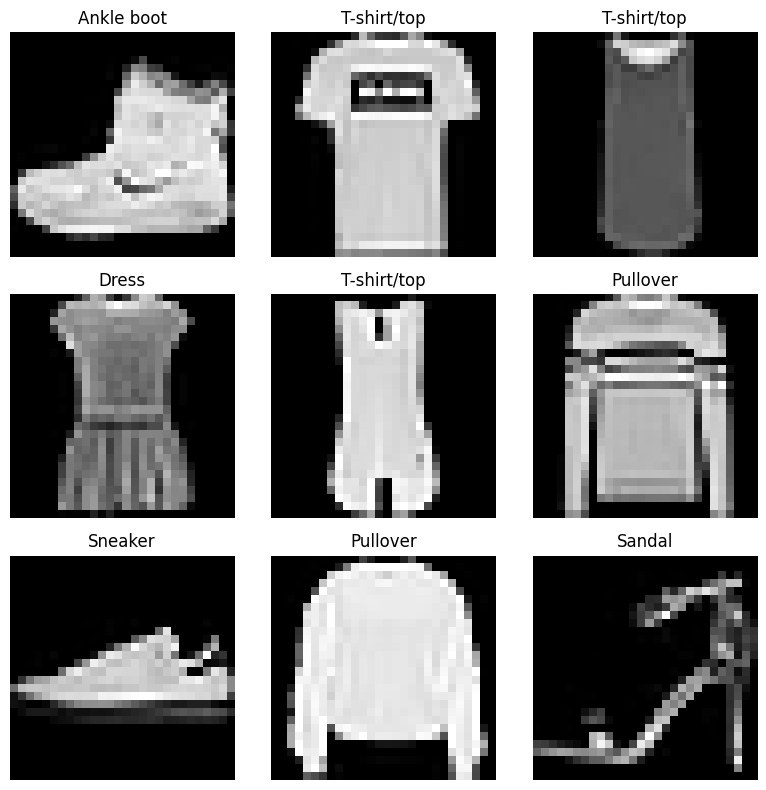

In [36]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'] # Las dejo como las originales, no vienen al caso su traducción

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

## Construcción del modelo

In [37]:
autoencoder = models.Sequential([
    # Codificador
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', strides=2),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', strides=2),

    # Decodificador
    layers.Conv2DTranspose(16, (3, 3), strides=2, activation='relu', padding='same'),
    layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same'),
    layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')
])

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 14, 14, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 32)     │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

In [38]:
epochs = 15
batch_size = 128

history = autoencoder.fit(
    x_train, x_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 172ms/step - loss: 0.0202 - val_loss: 0.0058
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 171ms/step - loss: 0.0044 - val_loss: 0.0034
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 173ms/step - loss: 0.0028 - val_loss: 0.0024
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 177ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 177ms/step - loss: 0.0018 - val_loss: 0.0017
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 172ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 172ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 174ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 175ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 172ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 179ms/step - loss: 9.9200e-04 - val_loss: 9.6608e-04
Epoch 12/15

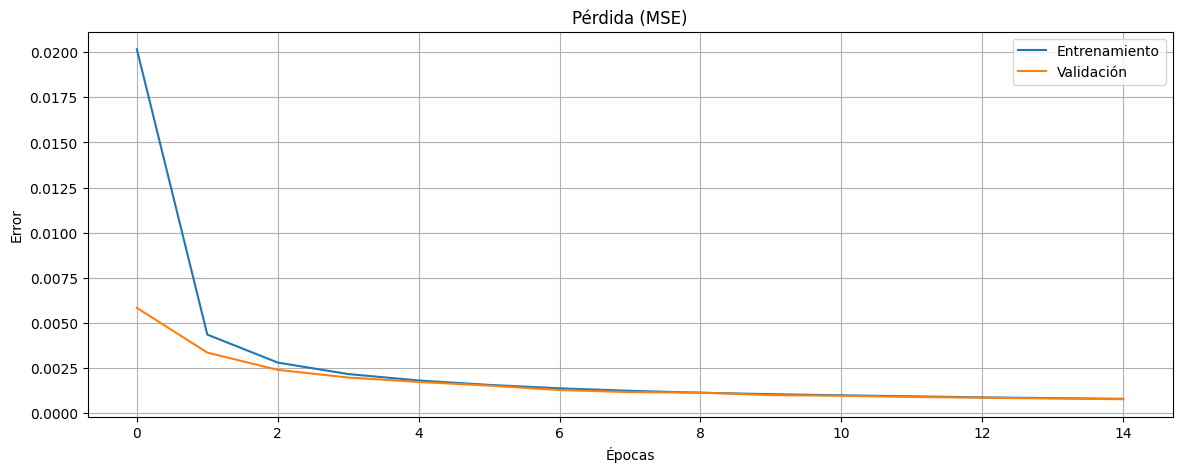

In [39]:
plt.figure(figsize=(14, 5))

# Gráfico de Pérdida (Loss)
plt.subplot(1, 1, 1) # Changed to 1,1,1 as there is only one plot now
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida (MSE)')
plt.xlabel('Épocas')
plt.ylabel('Error')
plt.legend()
plt.grid(True)

# The accuracy plot is removed as the metric is not available in history.

plt.show()

## Original vs reconstrucción

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


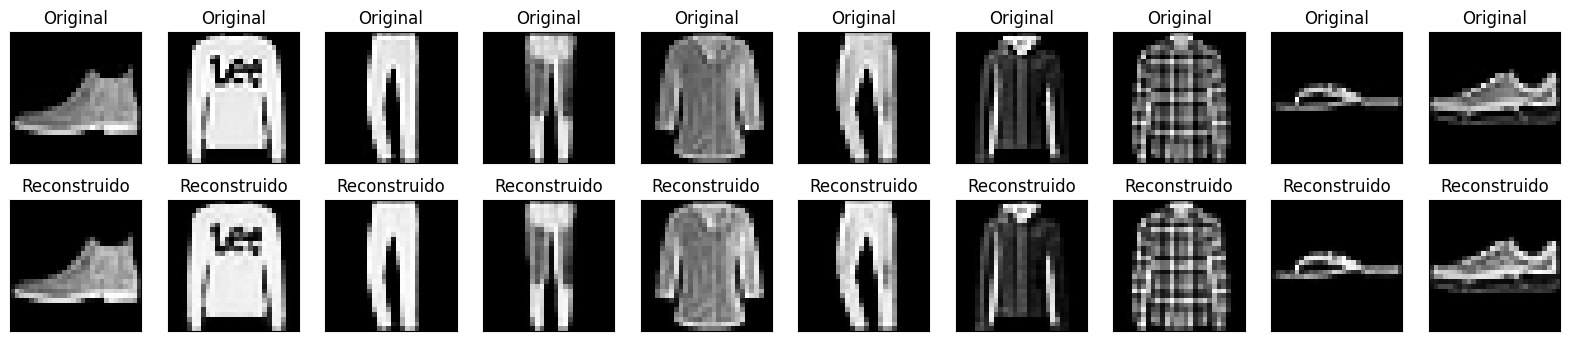

In [40]:
# Realizar predicciones
decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):

    # Imagen original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Imagen reconstruida
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstruido")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()